In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
sys.path.append(str(PROJECT_ROOT))

import torch
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)

from torch.utils.data import DataLoader

from ml.config import *
from ml.datasets.fusion_dataset import FusionDataset
from ml.models.fusion_model import FusionModel

print("="*70)
print("Fusion Model Evaluation")
print("="*70)
print("Device :", DEVICE)

PROJECT_ROOT : C:\Users\hp\Documents\Anemia_Fusion_Net_project
TRAIN_CSV    : C:\Users\hp\Documents\Anemia_Fusion_Net_project\data\processed\train.csv
VAL_CSV      : C:\Users\hp\Documents\Anemia_Fusion_Net_project\data\processed\valid.csv
IMAGE_DIR    : C:\Users\hp\Documents\Anemia_Fusion_Net_project\data\eye_image
Device       : cpu
Fusion Model Evaluation
Device : cpu


In [2]:
dataset = FusionDataset(
    csv_file=PROJECT_ROOT / "data/processed/fusion_data.csv",
    image_root=IMAGE_DIR
)

test_loader = DataLoader(
    dataset,
    batch_size=32,
    shuffle=False,
    num_workers=0
)

print("="*70)
print("Dataset Loaded")
print("="*70)
print("Samples :", len(dataset))

Dataset Loaded
Samples : 603


In [3]:
model = FusionModel().to(DEVICE)

model.load_state_dict(
    torch.load(
        MODEL_DIR / "fusion_best.pth",
        map_location=DEVICE
    )
)

model.eval()

print("="*70)
print("Best Model Loaded Successfully")
print("="*70)

Best Model Loaded Successfully


In [4]:
y_true = []
y_pred = []

with torch.no_grad():

    for images, clinical, geo, labels in test_loader:

        images = images.to(DEVICE)
        clinical = clinical.to(DEVICE)
        geo = geo.to(DEVICE)

        outputs = model(images, clinical, geo)

        predictions = torch.argmax(outputs, dim=1)

        y_true.extend(labels.numpy())
        y_pred.extend(predictions.cpu().numpy())

print("Prediction Completed")

Prediction Completed


In [5]:
accuracy = accuracy_score(y_true, y_pred)

print("="*70)
print("Accuracy")
print("="*70)
print(f"{accuracy*100:.2f}%")

Accuracy
88.56%


In [6]:
precision = precision_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)

print("="*70)
print("Classification Metrics")
print("="*70)

print("Precision :", precision)
print("Recall    :", recall)
print("F1 Score  :", f1)

Classification Metrics
Precision : 0.8074534161490683
Recall    : 0.9737827715355806
F1 Score  : 0.8828522920203735


In [7]:
print("="*70)
print("Classification Report")
print("="*70)

print(classification_report(y_true, y_pred))

Classification Report
              precision    recall  f1-score   support

           0       0.98      0.82      0.89       336
           1       0.81      0.97      0.88       267

    accuracy                           0.89       603
   macro avg       0.89      0.89      0.89       603
weighted avg       0.90      0.89      0.89       603



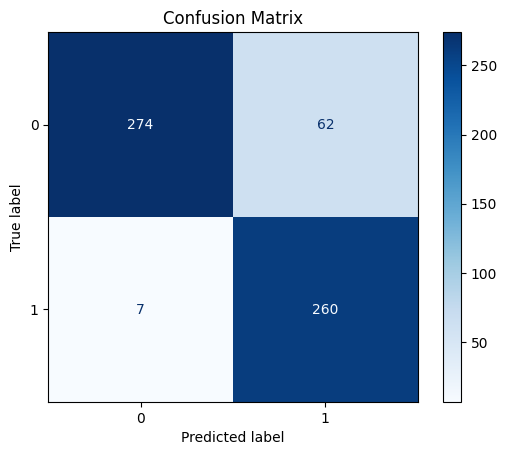

In [8]:
cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(cm)

disp.plot(cmap="Blues")

plt.title("Confusion Matrix")

plt.show()

In [9]:
print("="*70)
print("Sample Predictions")
print("="*70)

for i in range(20):

    print(
        f"Sample {i+1:02d} | "
        f"Actual={y_true[i]} | "
        f"Predicted={y_pred[i]}"
    )

Sample Predictions
Sample 01 | Actual=0 | Predicted=0
Sample 02 | Actual=0 | Predicted=0
Sample 03 | Actual=1 | Predicted=1
Sample 04 | Actual=0 | Predicted=0
Sample 05 | Actual=1 | Predicted=1
Sample 06 | Actual=1 | Predicted=1
Sample 07 | Actual=1 | Predicted=1
Sample 08 | Actual=1 | Predicted=1
Sample 09 | Actual=1 | Predicted=1
Sample 10 | Actual=1 | Predicted=1
Sample 11 | Actual=1 | Predicted=1
Sample 12 | Actual=1 | Predicted=1
Sample 13 | Actual=0 | Predicted=0
Sample 14 | Actual=1 | Predicted=1
Sample 15 | Actual=0 | Predicted=0
Sample 16 | Actual=1 | Predicted=1
Sample 17 | Actual=1 | Predicted=1
Sample 18 | Actual=0 | Predicted=0
Sample 19 | Actual=1 | Predicted=1
Sample 20 | Actual=1 | Predicted=1


In [10]:
print("="*70)
print("Model Information")
print("="*70)

print(model)

Model Information
FusionModel(
  (image_model): CNNModel(
    (backbone): EfficientNet(
      (conv_stem): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (bn1): BatchNormAct2d(
        32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True
        (drop): Identity()
        (act): SiLU(inplace=True)
      )
      (blocks): Sequential(
        (0): Sequential(
          (0): DepthwiseSeparableConv(
            (conv_dw): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
            (bn1): BatchNormAct2d(
              32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True
              (drop): Identity()
              (act): SiLU(inplace=True)
            )
            (aa): Identity()
            (se): SqueezeExcite(
              (conv_reduce): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
              (act1): SiLU(inplace=True)
              (conv_expand): Conv

In [11]:
print("="*70)
print("Evaluation Summary")
print("="*70)

print(f"Accuracy : {accuracy*100:.2f}%")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")

Evaluation Summary
Accuracy : 88.56%
Precision: 0.8075
Recall   : 0.9738
F1 Score : 0.8829


In [12]:
print("="*70)
print("Notebook 14 Completed Successfully")
print("="*70)

print("""
✓ Model Loaded

✓ Predictions Generated

✓ Accuracy Calculated

✓ Precision Calculated

✓ Recall Calculated

✓ F1 Score Calculated

✓ Confusion Matrix Generated

Project Evaluation Completed Successfully.
""")

Notebook 14 Completed Successfully

✓ Model Loaded

✓ Predictions Generated

✓ Accuracy Calculated

✓ Precision Calculated

✓ Recall Calculated

✓ F1 Score Calculated

✓ Confusion Matrix Generated

Project Evaluation Completed Successfully.

